In [14]:
# Análisis de rendimiento: procesamiento secuencial y paralelo

Este notebook analiza los resultados obtenidos mediante las versiones
secuencial y paralela del procesamiento de datos.

Se calculan:

- Tiempos promedio de ejecución.
- Speedup.
- Efficiency.
- Comparación entre procesamiento secuencial y paralelo.
- Gráficas de rendimiento.

SyntaxError: invalid syntax (1705207081.py, line 3)

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [16]:
secuencial = pd.read_csv("../resultados/secuencial.csv")
paralelo = pd.read_csv("../resultados/paralelo.csv")

print("Resultados secuenciales:")
display(secuencial)

print("Resultados paralelos:")
display(paralelo)

Resultados secuenciales:


,prueba,tiempo_segundos
0,1,2.862907
1,2,2.512996
2,3,2.504060
3,promedio,2.626654


Resultados paralelos:


,workers,prueba,tiempo_segundos
0,1,1,7.589091
1,1,2,7.985176
2,1,3,7.517039
3,2,1,4.951731
4,2,2,5.047445
5,2,3,4.842757
6,4,1,3.366138
7,4,2,3.362549
8,4,3,3.577093


In [17]:
# Tiempo promedio de la versión secuencial
promedio_secuencial = secuencial.loc[
    secuencial["prueba"] == "promedio",
    "tiempo_segundos"
].iloc[0]

# Tiempo promedio de cada configuración paralela
promedio_paralelo = (
    paralelo
    .groupby("workers")["tiempo_segundos"]
    .mean()
    .reset_index()
)

print(f"Tiempo promedio secuencial: {promedio_secuencial:.6f} segundos")

print("\nTiempos promedio paralelos:")
display(promedio_paralelo)

Tiempo promedio secuencial: 2.626654 segundos

Tiempos promedio paralelos:


,workers,tiempo_segundos
0,1,7.697102
1,2,4.947311
2,4,3.435260


In [18]:
analisis = promedio_paralelo.copy()

# T1 = tiempo promedio usando 1 worker
tiempo_1_worker = analisis.loc[
    analisis["workers"] == 1,
    "tiempo_segundos"
].iloc[0]

# Cálculo de Speedup
analisis["speedup"] = (
    tiempo_1_worker / analisis["tiempo_segundos"]
)

# Cálculo de Efficiency
analisis["efficiency"] = (
    analisis["speedup"] / analisis["workers"]
)

display(analisis)

,workers,tiempo_segundos,speedup,efficiency
0,1,7.697102,1.000000,1.000000
1,2,4.947311,1.555815,0.777908
2,4,3.435260,2.240617,0.560154


In [19]:
analisis["comparacion_vs_secuencial"] = (
    promedio_secuencial / analisis["tiempo_segundos"]
)

display(analisis)

,workers,tiempo_segundos,speedup,efficiency,comparacion_vs_secuencial
0,1,7.697102,1.000000,1.000000,0.341252
1,2,4.947311,1.555815,0.777908,0.530926
2,4,3.435260,2.240617,0.560154,0.764616


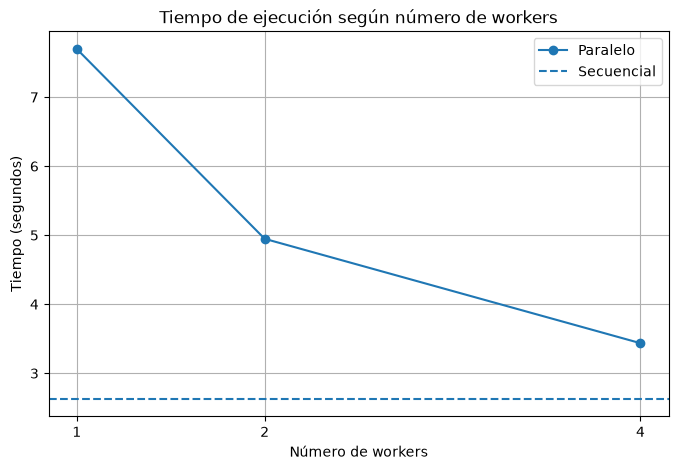

In [20]:
plt.figure(figsize=(8, 5))

plt.plot(
    analisis["workers"],
    analisis["tiempo_segundos"],
    marker="o",
    label="Paralelo"
)

plt.axhline(
    promedio_secuencial,
    linestyle="--",
    label="Secuencial"
)

plt.xlabel("Número de workers")
plt.ylabel("Tiempo (segundos)")
plt.title("Tiempo de ejecución según número de workers")
plt.xticks([1, 2, 4])
plt.legend()
plt.grid(True)
plt.show()

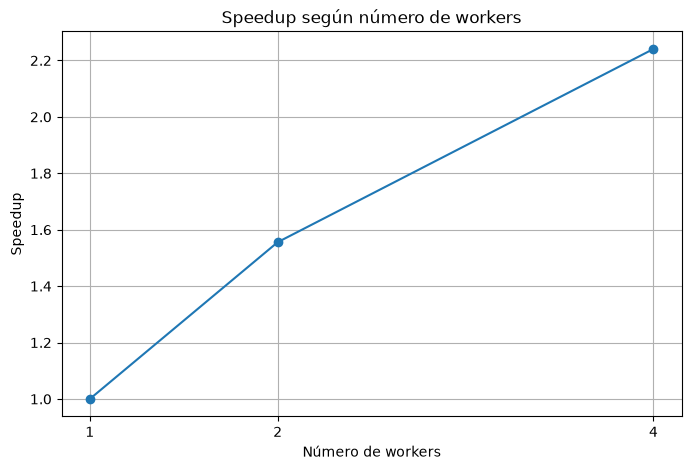

In [21]:
plt.figure(figsize=(8, 5))

plt.plot(
    analisis["workers"],
    analisis["speedup"],
    marker="o"
)

plt.xlabel("Número de workers")
plt.ylabel("Speedup")
plt.title("Speedup según número de workers")
plt.xticks([1, 2, 4])
plt.grid(True)
plt.show()

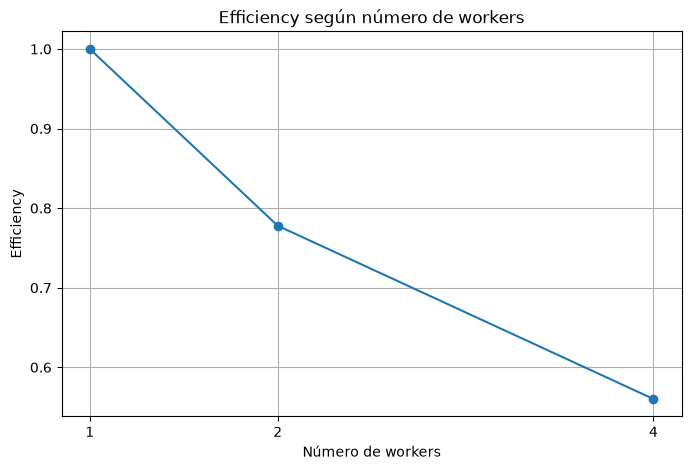

In [22]:
plt.figure(figsize=(8, 5))

plt.plot(
    analisis["workers"],
    analisis["efficiency"],
    marker="o"
)

plt.xlabel("Número de workers")
plt.ylabel("Efficiency")
plt.title("Efficiency según número de workers")
plt.xticks([1, 2, 4])
plt.grid(True)
plt.show()

In [23]:
tabla_final = analisis[
    [
        "workers",
        "tiempo_segundos",
        "speedup",
        "efficiency"
    ]
].copy()

tabla_final["tiempo_segundos"] = (
    tabla_final["tiempo_segundos"].round(6)
)

tabla_final["speedup"] = (
    tabla_final["speedup"].round(4)
)

tabla_final["efficiency"] = (
    tabla_final["efficiency"].round(4)
)

display(tabla_final)

,workers,tiempo_segundos,speedup,efficiency
0,1,7.697102,1.0000,1.0000
1,2,4.947311,1.5558,0.7779
2,4,3.435260,2.2406,0.5602


In [24]:
tabla_final.to_csv(
    "../resultados/analisis.csv",
    index=False
)

print("Archivo analisis.csv guardado correctamente.")

Archivo analisis.csv guardado correctamente.


In [ ]:
## Conclusiones

Los resultados muestran que el aumento del número de workers mejora el
tiempo de ejecución de la versión paralela. El tiempo promedio disminuye
de aproximadamente 7.70 segundos con 1 worker a 4.95 segundos con 2
workers y 3.44 segundos con 4 workers.

El Speedup aumenta al utilizar más workers. Se obtiene un Speedup de
aproximadamente 1.56 con 2 workers y 2.24 con 4 workers respecto a la
configuración paralela de 1 worker.

La Efficiency disminuye conforme aumenta el número de workers, pasando de
1.00 con 1 worker a aproximadamente 0.78 con 2 workers y 0.56 con
4 workers. Esto indica que el aumento de recursos no produce un
incremento proporcional del rendimiento.

Al comparar directamente con la implementación secuencial, cuyo tiempo
promedio es aproximadamente 2.63 segundos, la versión paralela todavía
presenta un mayor tiempo de ejecución incluso con 4 workers. Esto puede
explicarse por el costo adicional asociado con la creación de procesos y
la distribución y recopilación de los datos.

Por lo tanto, en las condiciones de esta prueba, 4 workers representa la
mejor configuración dentro de las opciones paralelas evaluadas, aunque
la implementación secuencial sigue siendo más rápida para este problema
y este entorno de ejecución.